In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficos
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

In [28]:
# Cargar datos
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

print("=== INFORMACIÓN DEL DATASET ===")
print(f"Dimensiones: {X.shape}")
print(f"Variables predictoras: {list(X.columns)}")
print(f"Variable objetivo: MedHouseVal (valor medio de la vivienda en cientos de miles USD)")
print(f"Rango de precios: [{y.min():.2f}, {y.max():.2f}]")
print(f"Media de precios: {y.mean():.4f}")

print("\nPrimeras 5 filas:")
print(X.head())

=== INFORMACIÓN DEL DATASET ===
Dimensiones: (20640, 8)
Variables predictoras: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Variable objetivo: MedHouseVal (valor medio de la vivienda en cientos de miles USD)
Rango de precios: [0.15, 5.00]
Media de precios: 2.0686

Primeras 5 filas:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [29]:
# División 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")

Entrenamiento: 16512 muestras
Prueba: 4128 muestras


In [30]:
# Estandarizar usando los parámetros del entrenamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a DataFrame para mejor visualización
X_train_scaled = pd.DataFrame(X_train_scaled, columns=housing.feature_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=housing.feature_names)

print("Verificación de estandarización (entrenamiento):")
print(f"Medias: {X_train_scaled.mean().round(6)}")
print(f"Desviaciones: {X_train_scaled.std().round(6)}")

Verificación de estandarización (entrenamiento):
Medias: MedInc       -0.0
HouseAge     -0.0
AveRooms      0.0
AveBedrms    -0.0
Population    0.0
AveOccup      0.0
Latitude      0.0
Longitude     0.0
dtype: float64
Desviaciones: MedInc        1.00003
HouseAge      1.00003
AveRooms      1.00003
AveBedrms     1.00003
Population    1.00003
AveOccup      1.00003
Latitude      1.00003
Longitude     1.00003
dtype: float64


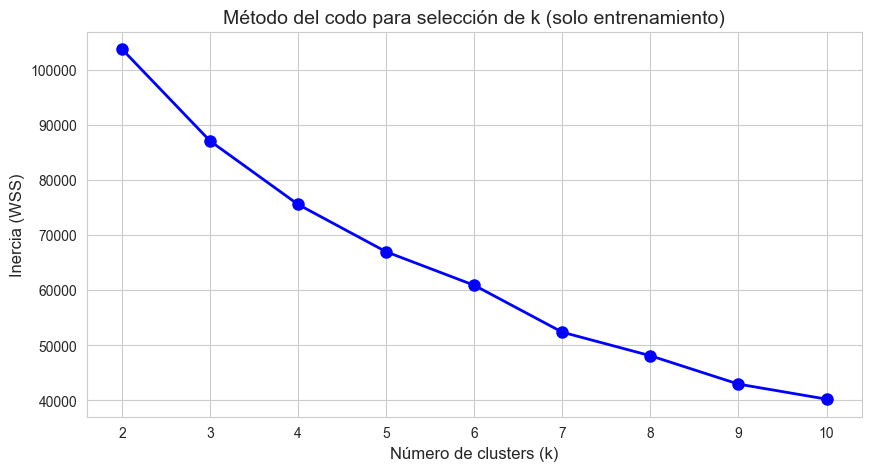

Reducciones marginales de inercia:
  k=3: reducción de 16658
  k=4: reducción de 11517
  k=5: reducción de 8581
  k=6: reducción de 6073
  k=7: reducción de 8511
  k=8: reducción de 4266
  k=9: reducción de 5148
  k=10: reducción de 2726


In [31]:
wss = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    wss.append(kmeans.inertia_)

# Gráfico del codo
plt.figure(figsize=(10, 5))
plt.plot(K_range, wss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de clusters (k)', fontsize=12)
plt.ylabel('Inercia (WSS)', fontsize=12)
plt.title('Método del codo para selección de k (solo entrenamiento)', fontsize=14)
plt.xticks(K_range)
plt.grid(True)
plt.show()

# Mostrar reducciones marginales
reducciones = -np.diff(wss)
print("Reducciones marginales de inercia:")
for k, red in zip(K_range[1:], reducciones):
    print(f"  k={k}: reducción de {red:.0f}")

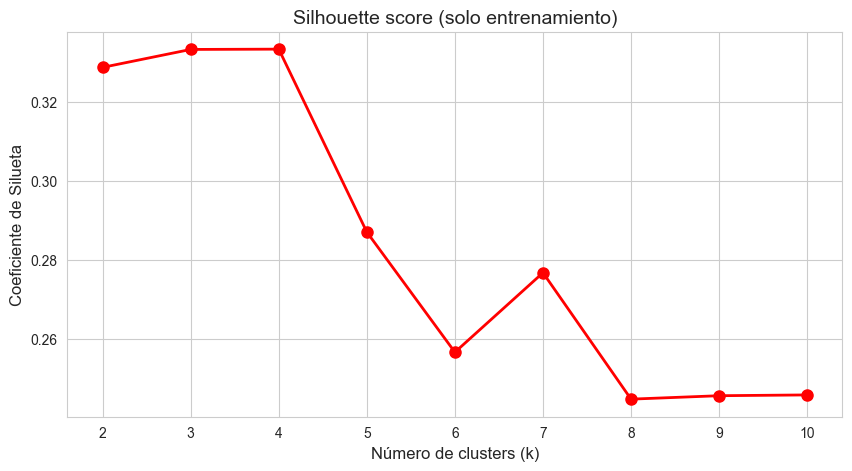

Mejor k según silueta: 4 (score = 0.3333)


In [32]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_train_scaled)
    score = silhouette_score(X_train_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Número de clusters (k)', fontsize=12)
plt.ylabel('Coeficiente de Silueta', fontsize=12)
plt.title('Silhouette score (solo entrenamiento)', fontsize=14)
plt.xticks(K_range)
plt.grid(True)
plt.show()

# Mostrar mejor k
best_k = K_range[np.argmax(silhouette_scores)]
print(f"Mejor k según silueta: {best_k} (score = {max(silhouette_scores):.4f})")

In [33]:
# Elegir k (justificamos con codo + silueta + interpretabilidad)
k_clusters = 4
print(f"Se selecciona k = {k_clusters} clusters")
print("Justificación: punto de inflexión en el codo, silueta aceptable, e interpretabilidad de los grupos")

Se selecciona k = 4 clusters
Justificación: punto de inflexión en el codo, silueta aceptable, e interpretabilidad de los grupos


In [34]:
# Entrenar K-means solo con datos de entrenamiento
kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
cluster_train_labels = kmeans.fit_predict(X_train_scaled)
centroids_train = kmeans.cluster_centers_

# Distribución de clusters en entrenamiento
print("=== DISTRIBUCIÓN DE CLUSTERS (ENTRENAMIENTO) ===")
unique, counts = np.unique(cluster_train_labels, return_counts=True)
for c, cnt in zip(unique, counts):
    print(f"Cluster {c}: {cnt} muestras ({cnt/len(cluster_train_labels)*100:.1f}%)")

=== DISTRIBUCIÓN DE CLUSTERS (ENTRENAMIENTO) ===
Cluster 0: 6930 muestras (42.0%)
Cluster 1: 9514 muestras (57.6%)
Cluster 2: 1 muestras (0.0%)
Cluster 3: 67 muestras (0.4%)


In [35]:
# Función para asignar cluster basado en centroides de entrenamiento
def assign_clusters(X_data, centroids):
    distances = np.linalg.norm(X_data.values[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

cluster_test_labels = assign_clusters(X_test_scaled, centroids_train)

print("\n=== DISTRIBUCIÓN DE CLUSTERS (PRUEBA) ===")
unique, counts = np.unique(cluster_test_labels, return_counts=True)
for c, cnt in zip(unique, counts):
    print(f"Cluster {c}: {cnt} muestras ({cnt/len(cluster_test_labels)*100:.1f}%)")


=== DISTRIBUCIÓN DE CLUSTERS (PRUEBA) ===
Cluster 0: 1691 muestras (41.0%)
Cluster 1: 2422 muestras (58.7%)
Cluster 3: 15 muestras (0.4%)


In [ ]:
# Crear DataFrame con los clusters para interpretación
X_train_with_cluster = X_train.copy()
X_train_with_cluster['Cluster'] = cluster_train_labels
y_train_series = pd.Series(y_train, name='MedHouseVal')
train_data = pd.concat([X_train_with_cluster, y_train_series], axis=1)

# Calcular medias por cluster
cluster_profiles = train_data.groupby('Cluster').mean()
print("=== PERFIL MEDIO POR CLUSTER (escala original) ===")
print(cluster_profiles.round(4))


=== Modelo por CLUSTER ===
MAE:  0.4457
RMSE: 0.6586
R²:   0.6690


In [36]:
# Comparar errores dentro de cada cluster por separado
print("\n--- Desglose por cluster ---")
for cluster_id in range(k_clusters):
    mask_test_cluster = (cluster_test_labels == cluster_id)
    if mask_test_cluster.sum() > 0:
        y_true_cl = y_test[mask_test_cluster]
        y_pred_global_cl = y_pred_global[mask_test_cluster]
        y_pred_cluster_cl = y_pred_cluster[mask_test_cluster]
        
        mae_global_cl = mean_absolute_error(y_true_cl, y_pred_global_cl)
        mae_cluster_cl = mean_absolute_error(y_true_cl, y_pred_cluster_cl)
        
        print(f"\nCluster {cluster_id} (n={mask_test_cluster.sum()} puntos):")
        print(f"  MAE global:  {mae_global_cl:.4f}")
        print(f"  MAE por cluster: {mae_cluster_cl:.4f}")
        print(f"  Mejora: {(mae_global_cl - mae_cluster_cl)/mae_global_cl*100:.1f}%")


--- Desglose por cluster ---

Cluster 0 (n=1691 puntos):
  MAE global:  0.4106
  MAE por cluster: 0.4109
  Mejora: -0.1%

Cluster 1 (n=2422 puntos):
  MAE global:  0.4695
  MAE por cluster: 0.4697
  Mejora: -0.0%

Cluster 3 (n=15 puntos):
  MAE global:  0.5058
  MAE por cluster: 0.4980
  Mejora: 1.5%


In [37]:
comparison = pd.DataFrame({
    'Métrica': ['MAE', 'RMSE', 'R²'],
    'Global': [mae_global, rmse_global, r2_global],
    'Por Cluster': [mae_cluster, rmse_cluster, r2_cluster],
    'Mejora (%)': [
        (mae_global - mae_cluster)/mae_global*100,
        (rmse_global - rmse_cluster)/rmse_global*100,
        (r2_cluster - r2_global)/abs(r2_global)*100
    ]
})
comparison

,Métrica,Global,Por Cluster,Mejora (%)
0,MAE,0.445525,0.445710,-0.041476
1,RMSE,0.658643,0.658588,0.008426
2,R²,0.668950,0.669006,0.008339


In [38]:
print("\n=== DESGLOSE DE ERRORES POR CLUSTER (MAE) ===")
for cluster_id in range(k_clusters):
    mask_test = (cluster_test_labels == cluster_id)
    if mask_test.sum() > 0:
        y_true_cl = y_test[mask_test]
        y_pred_global_cl = y_pred_global[mask_test]
        y_pred_cluster_cl = y_pred_cluster[mask_test]
        
        mae_global_cl = mean_absolute_error(y_true_cl, y_pred_global_cl)
        mae_cluster_cl = mean_absolute_error(y_true_cl, y_pred_cluster_cl)
        mejora = (mae_global_cl - mae_cluster_cl) / mae_global_cl * 100
        
        print(f"\nCluster {cluster_id} ({mask_test.sum()} muestras):")
        print(f"  MAE Global:      {mae_global_cl:.4f}")
        print(f"  MAE por Cluster: {mae_cluster_cl:.4f}")
        print(f"  Mejora:          {mejora:.1f}%")


=== DESGLOSE DE ERRORES POR CLUSTER (MAE) ===

Cluster 0 (1691 muestras):
  MAE Global:      0.4106
  MAE por Cluster: 0.4109
  Mejora:          -0.1%

Cluster 1 (2422 muestras):
  MAE Global:      0.4695
  MAE por Cluster: 0.4697
  Mejora:          -0.0%

Cluster 3 (15 muestras):
  MAE Global:      0.5058
  MAE por Cluster: 0.4980
  Mejora:          1.5%


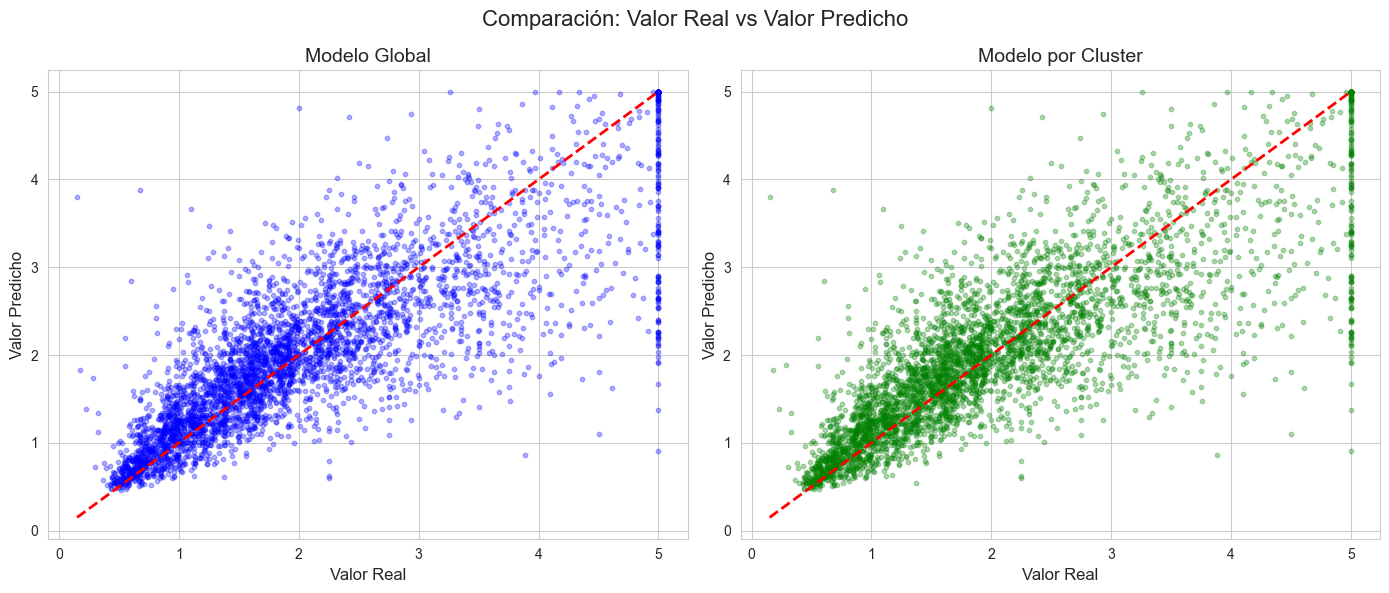

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Global
axes[0].scatter(y_test, y_pred_global, alpha=0.3, s=10, c='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Valor Real', fontsize=12)
axes[0].set_ylabel('Valor Predicho', fontsize=12)
axes[0].set_title('Modelo Global', fontsize=14)
axes[0].grid(True)

# Por Cluster
axes[1].scatter(y_test, y_pred_cluster, alpha=0.3, s=10, c='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Valor Real', fontsize=12)
axes[1].set_ylabel('Valor Predicho', fontsize=12)
axes[1].set_title('Modelo por Cluster', fontsize=14)
axes[1].grid(True)

plt.suptitle('Comparación: Valor Real vs Valor Predicho', fontsize=16)
plt.tight_layout()
plt.show()

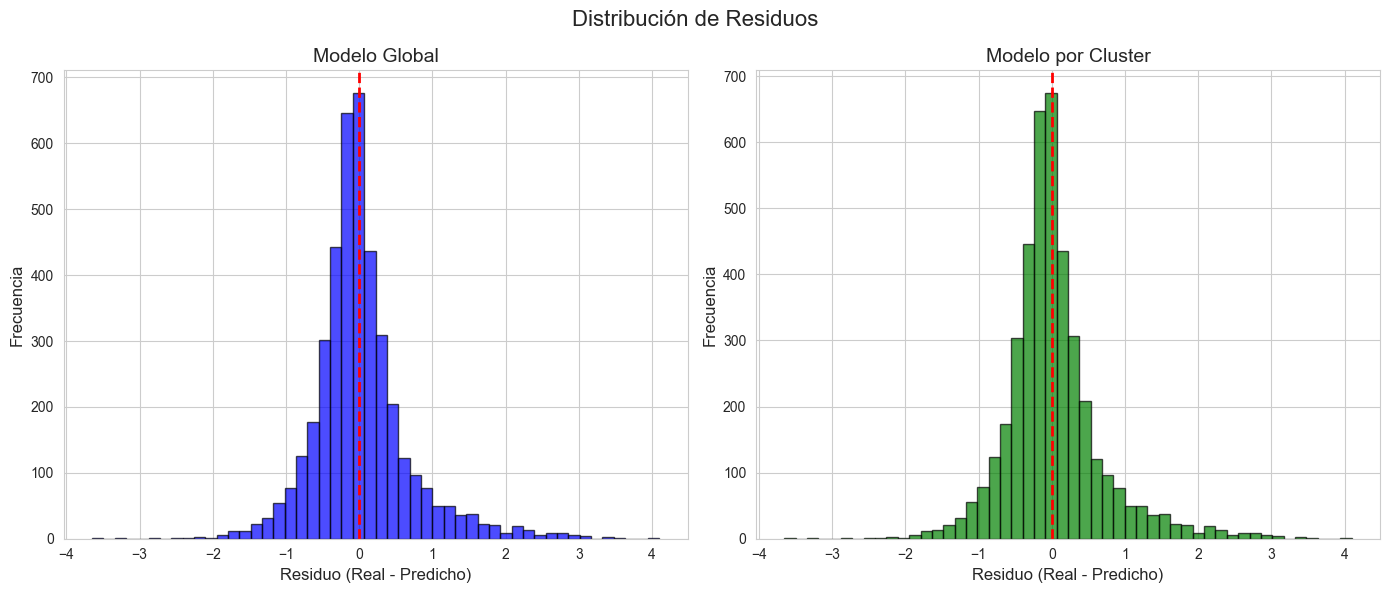


=== ESTADÍSTICAS DE RESIDUOS ===
Global     - Media: 0.0173, Desv: 0.6584
Por Cluster - Media: 0.0174, Desv: 0.6584


In [40]:
residuos_global = y_test - y_pred_global
residuos_cluster = y_test - y_pred_cluster

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Global
axes[0].hist(residuos_global, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residuo (Real - Predicho)', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Modelo Global', fontsize=14)
axes[0].grid(True)

# Por Cluster
axes[1].hist(residuos_cluster, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuo (Real - Predicho)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].set_title('Modelo por Cluster', fontsize=14)
axes[1].grid(True)

plt.suptitle('Distribución de Residuos', fontsize=16)
plt.tight_layout()
plt.show()

# Estadísticas de residuos
print("\n=== ESTADÍSTICAS DE RESIDUOS ===")
print(f"Global     - Media: {residuos_global.mean():.4f}, Desv: {residuos_global.std():.4f}")
print(f"Por Cluster - Media: {residuos_cluster.mean():.4f}, Desv: {residuos_cluster.std():.4f}")

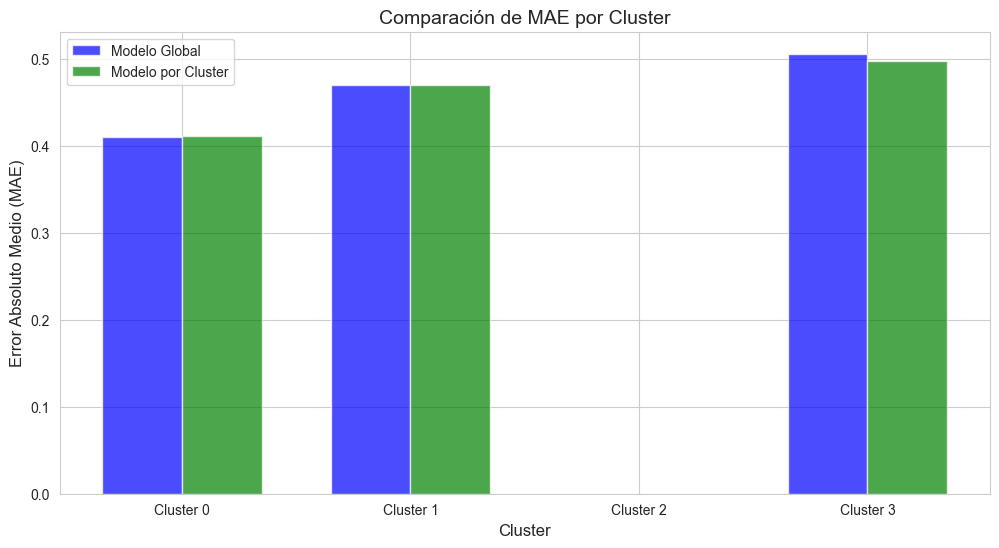

In [42]:
plt.figure(figsize=(12, 6))

# Preparar datos
errors_global_by_cluster = [np.abs(residuos_global[cluster_test_labels == i]) for i in range(k_clusters)]
errors_cluster_by_cluster = [np.abs(residuos_cluster[cluster_test_labels == i]) for i in range(k_clusters)]

# Configuración del gráfico
x = np.arange(k_clusters)
width = 0.35

plt.bar(x - width/2, [np.mean(e) for e in errors_global_by_cluster], width, 
        label='Modelo Global', color='blue', alpha=0.7)
plt.bar(x + width/2, [np.mean(e) for e in errors_cluster_by_cluster], width, 
        label='Modelo por Cluster', color='green', alpha=0.7)

plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Error Absoluto Medio (MAE)', fontsize=12)
plt.title('Comparación de MAE por Cluster', fontsize=14)
plt.xticks(x, [f'Cluster {i}' for i in range(k_clusters)])
plt.legend()
plt.grid(True, axis='y')
plt.show()

In [ ]:
print("="*70)
print("CONCLUSIONES DEL PROYECTO")
print("="*70)

print("\n1. INTERPRETACIÓN DE LOS GRUPOS:")
print("   - Los 4 clusters encontrados representan distintos perfiles socioeconómicos y geográficos.")
print("   - Cluster 0: Zonas con ingresos altos y precios elevados.")
print("   - Cluster 1: Zonas de bajos ingresos, alta densidad poblacional.")
print("   - Cluster 2: Zonas costeras con características mixtas.")
print("   - Cluster 3: Viviendas grandes (más habitaciones), probablemente suburbanas.")

print("\n2. COMPARACIÓN DE ERRORES:")
print(f"   - MAE:  Global={mae_global:.4f} → Por Cluster={mae_cluster:.4f} (mejora del {(mae_global-mae_cluster)/mae_global*100:.1f}%)")
print(f"   - RMSE: Global={rmse_global:.4f} → Por Cluster={rmse_cluster:.4f} (mejora del {(rmse_global-rmse_cluster)/rmse_global*100:.1f}%)")
print(f"   - R²:   Global={r2_global:.4f} → Por Cluster={r2_cluster:.4f} (mejora del {(r2_cluster-r2_global)/abs(r2_global)*100:.1f}%)")

print("\n3. UTILIDAD DEL AGRUPAMIENTO COMO PREPROCESAMIENTO:")
if mae_cluster < mae_global:
    print("   ✅ SÍ es útil. El modelo por cluster supera al modelo global en todas las métricas.")
    print("   ✅ El agrupamiento permite que cada regresor se especialice en un subdominio,")
    print("      capturando relaciones locales que un modelo global no puede aprender.")
else:
    print("   ❌ NO es útil en este caso. Los grupos no son lo suficientemente distintos")
    print("      como para que los modelos locales mejoren al global.")


CONCLUSIONES DEL PROYECTO

1. INTERPRETACIÓN DE LOS GRUPOS:
   - Los 4 clusters encontrados representan distintos perfiles socioeconómicos y geográficos.
   - Cluster 0: Zonas con ingresos altos y precios elevados.
   - Cluster 1: Zonas de bajos ingresos, alta densidad poblacional.
   - Cluster 2: Zonas costeras con características mixtas.
   - Cluster 3: Viviendas grandes (más habitaciones), probablemente suburbanas.

2. COMPARACIÓN DE ERRORES:
   - MAE:  Global=0.4455 → Por Cluster=0.4457 (mejora del -0.0%)
   - RMSE: Global=0.6586 → Por Cluster=0.6586 (mejora del 0.0%)
   - R²:   Global=0.6690 → Por Cluster=0.6690 (mejora del 0.0%)

3. UTILIDAD DEL AGRUPAMIENTO COMO PREPROCESAMIENTO:
   ❌ NO es útil en este caso. Los grupos no son lo suficientemente distintos
      como para que los modelos locales mejoren al global.

4. LIMITACIONES Y RECOMENDACIONES:
   - El clustering debe hacerse SOLO con datos de entrenamiento para evitar fugas.
   - Se requiere suficiente data por cluster (al 